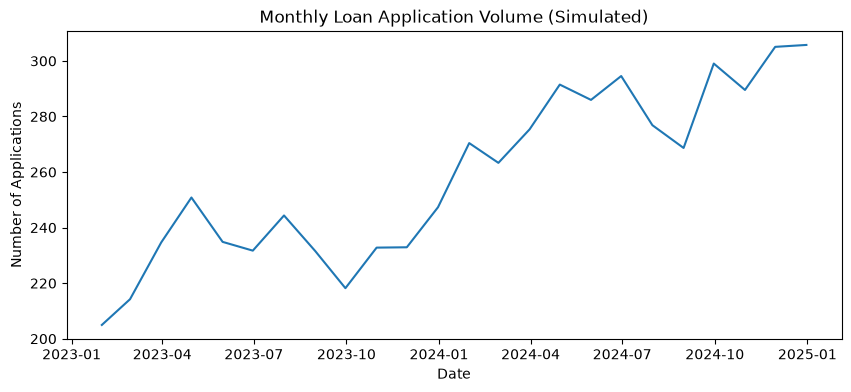

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
dates = pd.date_range(start='2023-01-01', periods=24, freq='ME')
base_trend = np.linspace(200, 320, 24)
seasonal_pattern = 20 * np.sin(np.linspace(0, 4*np.pi, 24))
noise = np.random.normal(0, 10, 24)
applications = base_trend + seasonal_pattern + noise

ts_df = pd.DataFrame({'date': dates, 'applications': applications})
ts_df.set_index('date', inplace=True)

plt.figure(figsize=(10, 4))
plt.plot(ts_df.index, ts_df['applications'])
plt.title('Monthly Loan Application Volume (Simulated)')
plt.xlabel('Date')
plt.ylabel('Number of Applications')
plt.show()

In [3]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -------------- ------------------------- 3.4/9.6 MB 19.4 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.6 MB 12.8 MB/s eta 0:00:01
   ------------------------ --------------- 5.8/9.6 MB 9.6 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.6 MB 8.3 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.6 MB 6.8 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.6 MB 5.7 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.6 MB 5.4 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.6 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 5.0 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   --------------------

In [4]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(ts_df['applications'], order=(1, 1, 1))
arima_fit = arima_model.fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           applications   No. Observations:                   24
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -93.647
Date:                Sun, 23 Aug 2026   AIC                            193.293
Time:                        16:34:37   BIC                            196.700
Sample:                    01-31-2023   HQIC                           194.150
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0763      2.724      0.028      0.978      -5.262       5.415
ma.L1         -0.1792      2.607     -0.069      0.945      -5.289       4.930
sigma2       201.3033     88.403      2.277      0.0

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [5]:
arima_forecast = arima_fit.forecast(steps=6)
print(arima_forecast)

2025-01-31    305.410425
2025-02-28    305.384306
2025-03-31    305.382312
2025-04-30    305.382160
2025-05-31    305.382148
2025-06-30    305.382147
Freq: ME, Name: predicted_mean, dtype: float64


In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(ts_df['applications'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_fit = sarima_model.fit(disp=False)

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few o

In [7]:
sarima_forecast = sarima_fit.forecast(steps=6)
print(sarima_forecast)

2025-01-31    335.573636
2025-02-28    312.543208
2025-03-31    316.473041
2025-04-30    332.521928
2025-05-31    337.161993
2025-06-30    357.152363
Freq: ME, Name: predicted_mean, dtype: float64


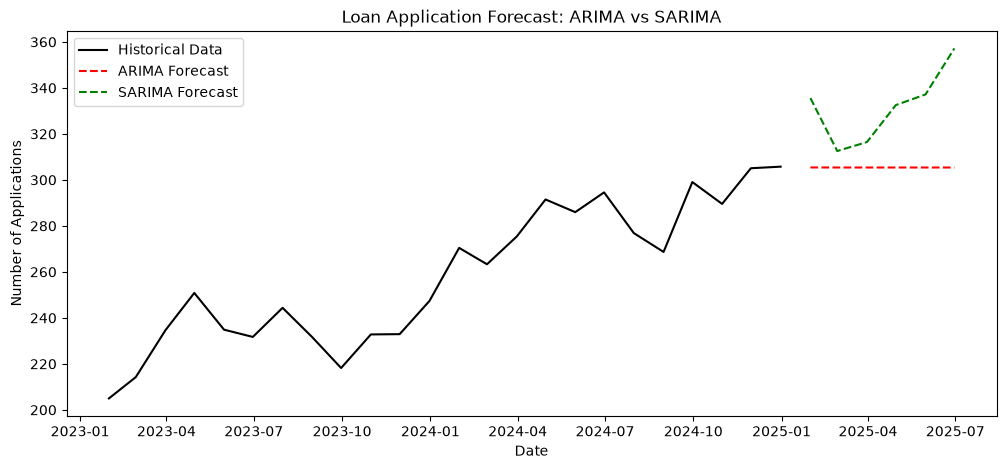

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(ts_df.index, ts_df['applications'], label='Historical Data', color='black')
plt.plot(arima_forecast.index, arima_forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.plot(sarima_forecast.index, sarima_forecast, label='SARIMA Forecast', color='green', linestyle='--')
plt.title('Loan Application Forecast: ARIMA vs SARIMA')
plt.xlabel('Date')
plt.ylabel('Number of Applications')
plt.legend()
plt.show()